In [1]:
import re
import json
import glob

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import scienceplots
plt.style.use(["ieee", "no-latex"])
plt.rcParams["figure.dpi"] = 300

## Metrics

In [3]:
df = pd.concat([pd.read_csv(x) for x in glob.glob("../data/evals/*.csv")], ignore_index=True)
df.head()

,model,stemming_model,stemming_eval,metric,k,value
0,sentence-transformers/multi-qa-distilbert-cos-v1,False,False,NDCG,1,0.08465
1,sentence-transformers/multi-qa-distilbert-cos-v1,False,False,NDCG,3,0.11817
2,sentence-transformers/multi-qa-distilbert-cos-v1,False,False,NDCG,5,0.13046
3,sentence-transformers/multi-qa-distilbert-cos-v1,False,False,NDCG,10,0.14408
4,sentence-transformers/multi-qa-distilbert-cos-v1,False,False,NDCG,100,0.18519


In [4]:
df["fine_tuned"] = df["model"].str.contains("ams")
df["category"] = np.where(df["model"].str.contains("bow|tfidf|doc2vec|fasttext"), "traditional", "bert")
df["model_name"] = (df["model"].str.split("/") 
    .str[-1] 
    .str.replace("ams-|-stem|\.joblib|\.gensim", "", regex=True)
)

df = df.drop(columns=["model"])
df.head()

,stemming_model,stemming_eval,metric,k,value,fine_tuned,category,model_name
0,False,False,NDCG,1,0.08465,False,bert,multi-qa-distilbert-cos-v1
1,False,False,NDCG,3,0.11817,False,bert,multi-qa-distilbert-cos-v1
2,False,False,NDCG,5,0.13046,False,bert,multi-qa-distilbert-cos-v1
3,False,False,NDCG,10,0.14408,False,bert,multi-qa-distilbert-cos-v1
4,False,False,NDCG,100,0.18519,False,bert,multi-qa-distilbert-cos-v1


In [5]:
df.to_csv("../data/eval-all.csv", index=False, sep=";", decimal=",")

In [6]:
dd = df[(df["k"] == 5) & (~df["stemming_eval"])].pivot_table(index=["stemming_model", "model_name"], columns=["fine_tuned", "metric"], values="value")
dd

fine_tuned                                   False                             \
metric                                         MAP     NDCG        P   Recall   
stemming_model model_name                                                       
False          all-mpnet-base-v2           0.10934  0.12181  0.03190  0.15949   
               bow                             NaN      NaN      NaN      NaN   
               doc2vec                         NaN      NaN      NaN      NaN   
               fasttext                        NaN      NaN      NaN      NaN   
               msmarco-MiniLM-L6-cos-v5    0.11131  0.12401  0.03247  0.16233   
               msmarco-distilbert-cos-v5   0.06272  0.07093  0.01919  0.09594   
               multi-qa-MiniLM-L6-cos-v1   0.12615  0.13888  0.03546  0.17732   
               multi-qa-distilbert-cos-v1  0.11671  0.13046  0.03440  0.17198   
               tfidf                           NaN      NaN      NaN      NaN   
True           all-mpnet-base-v2               NaN      NaN      NaN      NaN   
               bow                             NaN      NaN      NaN      NaN   
               doc2vec                         NaN      NaN      NaN      NaN   
               fasttext                        NaN      NaN      NaN      NaN   
               msmarco-MiniLM-L6-cos-v5        NaN      NaN      NaN      NaN   
               msmarco-distilbert-cos-v5       NaN      NaN      NaN      NaN   
               multi-qa-MiniLM-L6-cos-v1       NaN      NaN      NaN      NaN   
               multi-qa-distilbert-cos-v1      NaN      NaN      NaN      NaN   
               tfidf                           NaN      NaN      NaN      NaN   

fine_tuned                                   True                              
metric                                         MAP     NDCG        P   Recall  
stemming_model model_name                                                      
False          all-mpnet-base-v2           0.23376  0.25684  0.06528  0.32639  
               bow                         0.30906  0.33920  0.08596  0.42981  
               doc2vec                     0.06968  0.08048  0.02267  0.11333  
               fasttext                    0.02164  0.02592  0.00780  0.03901  
               msmarco-MiniLM-L6-cos-v5    0.19294  0.21365  0.05524  0.27618  
               msmarco-distilbert-cos-v5   0.23018  0.25278  0.06417  0.32087  
               multi-qa-MiniLM-L6-cos-v1   0.20484  0.22638  0.05828  0.29142  
               multi-qa-distilbert-cos-v1  0.24058  0.26459  0.06738  0.33689  
               tfidf                       0.49965  0.53945  0.13174  0.65872  
True           all-mpnet-base-v2           0.22823  0.25088  0.06383  0.31915  
               bow                         0.27651  0.30787  0.08059  0.40295  
               doc2vec                     0.06704  0.07781  0.02210  0.11049  
               fasttext                    0.02205  0.02661  0.00811  0.04056  
               msmarco-MiniLM-L6-cos-v5    0.16426  0.18265  0.04764  0.23820  
               msmarco-distilbert-cos-v5   0.21728  0.23867  0.06061  0.30305  
               multi-qa-MiniLM-L6-cos-v1   0.19236  0.21268  0.05481  0.27403  
               multi-qa-distilbert-cos-v1  0.22861  0.25127  0.06390  0.31950  
               tfidf                       0.49713  0.53713  0.13145  0.65725

## Training History

In [9]:
train_history = []

for file_path in glob.glob("../data/tuning-logs/*.log"):
    with open(file_path, "r") as f:
        current_run = {"max_epochs": int(re.search(r"\d+", file_path).group(0))}
        for line in f:
            try:
                if line.startswith("Namespace"):
                    current_run["model"] = re.search(r"model_name='(.+?)'", line).group(1)[22:]
                    current_run["stemming"] = "stemming=True" in line

                if line.startswith("{'loss':"):
                    line = line.replace("'", "\"").replace("inf", "-1").replace("nan", "-1")
                    parsed = json.loads(line)
                    train_history.append({
                        **current_run,
                        "epoch": parsed["epoch"],
                        "epoch_ceil": int(np.ceil(parsed["epoch"])),
                        "loss": parsed["loss"],
                    })
            except:
                print(line)

In [10]:
df_history = pd.DataFrame(train_history)
df_history = df_history.groupby(["max_epochs", "model", "stemming", "epoch_ceil"]).mean().reset_index() # summarize per epoch
df_history

,max_epochs,model,stemming,epoch_ceil,epoch,loss
0,10,all-mpnet-base-v2,False,1,0.500,0.916211
1,10,all-mpnet-base-v2,False,2,1.485,0.598885
2,10,all-mpnet-base-v2,False,3,2.485,0.353220
3,10,all-mpnet-base-v2,False,4,3.495,0.219075
4,10,all-mpnet-base-v2,False,5,4.495,0.127065
...,...,...,...,...,...,...
95,10,multi-qa-distilbert-cos-v1,True,6,5.505,0.037380
96,10,multi-qa-distilbert-cos-v1,True,7,6.505,0.022535
97,10,multi-qa-distilbert-cos-v1,True,8,7.515,0.016250
98,10,multi-qa-distilbert-cos-v1,True,9,8.515,0.012050


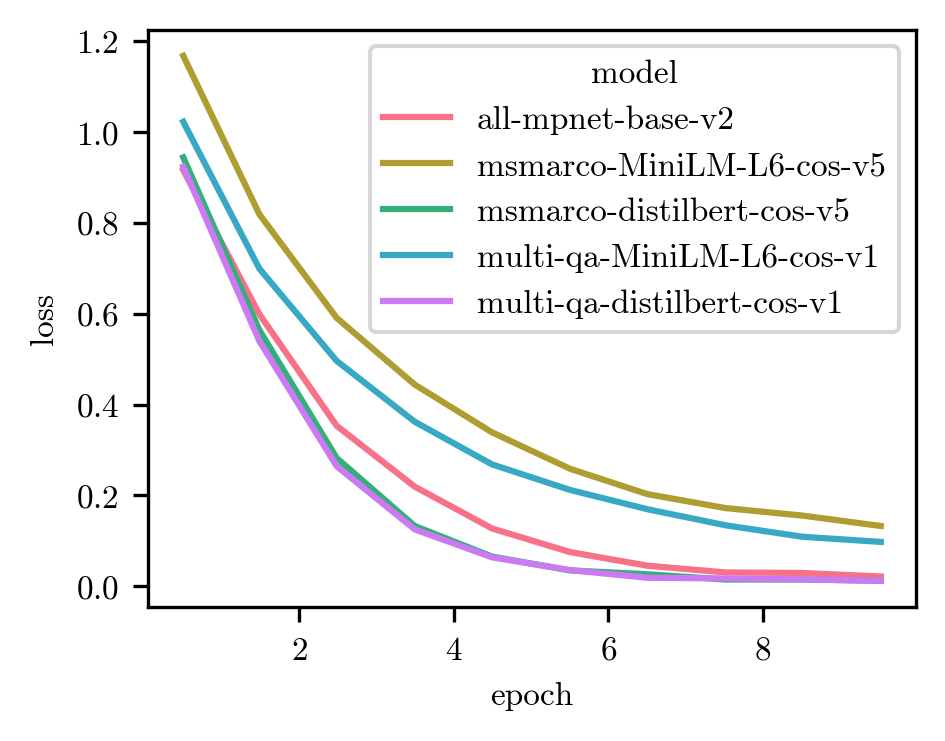

In [11]:
dd_filters = (df_history["stemming"] == False) & (df_history["max_epochs"] == 10)

sns.lineplot(df_history[dd_filters], x="epoch", y="loss", hue="model")
plt.show()

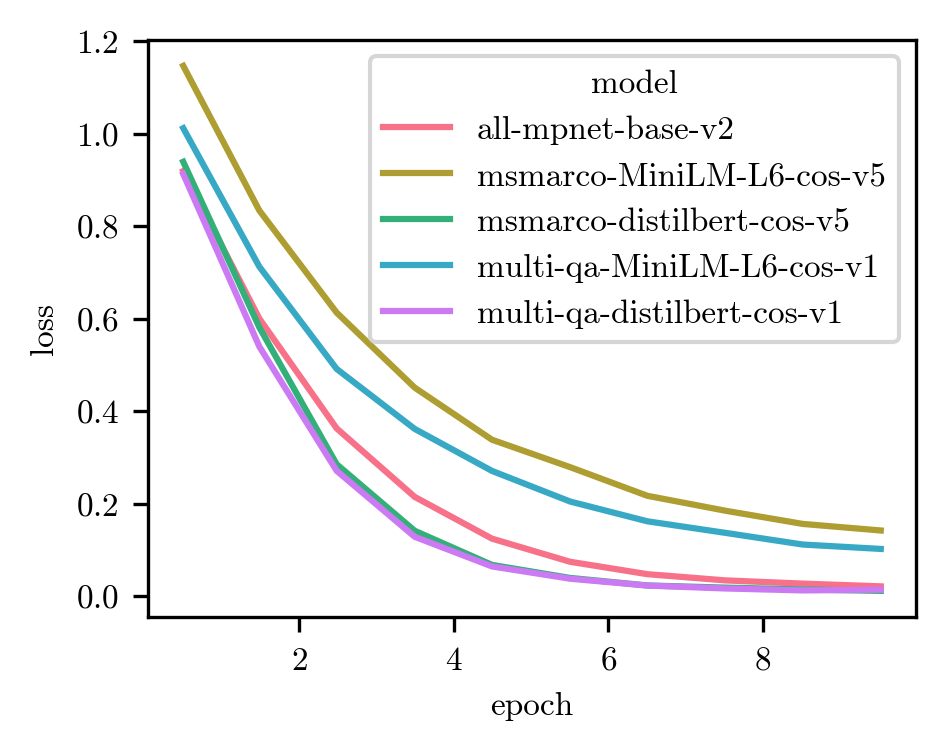

In [12]:
dd_filters = (df_history["stemming"] == True) & (df_history["max_epochs"] == 10)

sns.lineplot(df_history[dd_filters], x="epoch", y="loss", hue="model")
plt.show()